
# CAR PRICE PREDICTION SYSTEM USING MACHINE LEARNING
Made By:
- Talha Gillani (2510158)
- Ahsan Javed (2510150)
- Usaid Malik (2510159)

## Project Overview
###This project predicts the price of a car based on different features such as:
- Car Make
- Fuel Type
- Transmission
- Drivetrain
- Year
- Kilometer Driven
- Engine Capacity

##Machine Learning Regression algorithms are used to train the model and predict car prices accurately.

## Objectives
- Perform data preprocessing
- Analyze relationships between features
- Train a regression model
- Predict car prices using user inputs
- Evaluate model performance


# **1. Loading, Cleaning & Preprocessing Stage**

**IMPORTING REQUIRED LIBRARIES**

In [1]:

# DATA MANIPULATION LIBRARIES
import pandas as pd
import numpy as np

# DATA VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING LIBRARIES
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# MODEL EVALUATION LIBRARIES
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# IGNORE WARNING MESSAGES
import warnings
warnings.filterwarnings('ignore')

# DISPLAY SETTINGS
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


**LOADING DATASET**

In [2]:

# LOAD CSV FILE
df = pd.read_csv('/content/car details v4.csv')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


**DISPLAYING ROWS**

In [3]:

df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


**DATASET SHAPE**

In [4]:

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2059
Number of Columns : 20


**COLUMN NAMES**

In [5]:

print(df.columns)

Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')


**DATASET INFORMATION**

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

**STATISTICAL SUMMARY**

In [7]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


**CHECKING MISSING VALUES**

In [8]:
missing_values = df.isnull().sum()

print(missing_values)

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64


**VISUALIZING MISSING VALUES**

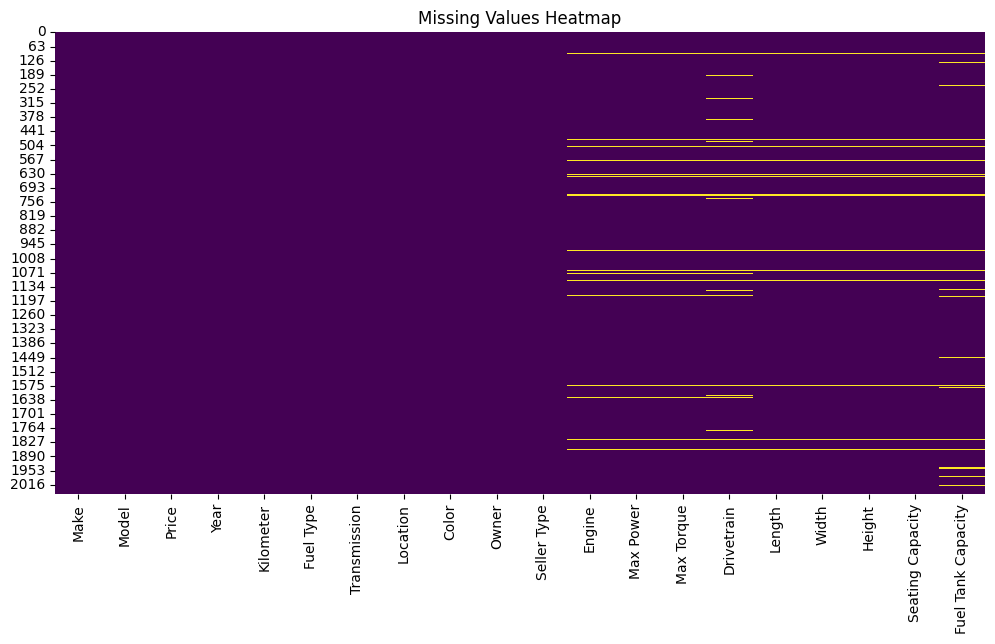

In [9]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

**CHECKING DUPLICATE RECORDS**

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicate_count)

Number of Duplicate Rows : 0


**REMOVING DUPLICATES**

In [11]:
df = df.drop_duplicates()

print("Duplicate Rows Removed Successfully!")

Duplicate Rows Removed Successfully!


**FINAL DATASET SHAPE AFTER CLEANING**

In [12]:
print(df.shape)

(2059, 20)


**SELECTING IMPORTANT FEATURES**

In [13]:
df = df[[
    'Make',
    'Model',
    'Year',
    'Kilometer',
    'Fuel Type',
    'Transmission',
    'Drivetrain',
    'Engine',
    'Price'
]]

print("Selected Columns Successfully!")

Selected Columns Successfully!


**DISPLAYING UPDATED DATASET**

In [14]:
df.head()

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Drivetrain,Engine,Price
0,Honda,Amaze 1.2 VX i-VTEC,2017,87150,Petrol,Manual,FWD,1198 cc,505000
1,Maruti Suzuki,Swift DZire VDI,2014,75000,Diesel,Manual,FWD,1248 cc,450000
2,Hyundai,i10 Magna 1.2 Kappa2,2011,67000,Petrol,Manual,FWD,1197 cc,220000
3,Toyota,Glanza G,2019,37500,Petrol,Manual,FWD,1197 cc,799000
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],2018,69000,Diesel,Manual,RWD,2393 cc,1950000


**CHECKING NULL VALUES**

In [15]:
print(df.isnull().sum())

Make              0
Model             0
Year              0
Kilometer         0
Fuel Type         0
Transmission      0
Drivetrain      136
Engine           80
Price             0
dtype: int64


**REMOVING NULL VALUES**

In [16]:
df = df.dropna()

print("Missing Values Removed Successfully!")

Missing Values Removed Successfully!


**DATASET SHAPE AFTER NULL REMOVAL**

In [17]:
print(df.shape)

(1916, 9)


**CLEANING MAKE COLUMN**

In [18]:
df['Make'] = df['Make'].str.strip()
df['Make'] = df['Make'].str.title()

print(df['Make'].unique()[:10])

['Honda' 'Maruti Suzuki' 'Hyundai' 'Toyota' 'Mercedes-Benz' 'Bmw' 'Skoda'
 'Nissan' 'Renault' 'Tata']


**CLEANING MODEL COLUMN (BASE MODEL ONLY)**

In [19]:
df['Model'] = df['Model'].str.strip()
df['Model'] = df['Model'].str.lower()

# remove special characters
df['Model'] = df['Model'].str.replace('-', ' ')
df['Model'] = df['Model'].str.replace('(', '')
df['Model'] = df['Model'].str.replace(')', '')
df['Model'] = df['Model'].str.replace(',', '')
df['Model'] = df['Model'].str.replace(r'\s+', ' ', regex=True)

# extract BASE MODEL (first word only)
df['Model'] = df['Model'].str.split().str[0]

# final formatting
df['Model'] = df['Model'].str.title()

print(df['Model'].unique()[:20])

['Amaze' 'Swift' 'I10' 'Glanza' 'Innova' 'Ciaz' 'Cla' 'X1' 'Octavia'
 'Terrano' 'Elite' 'Kwid' 'Harrier' 'Polo' 'Celerio' 'Alto' 'Baleno'
 'Wagon' 'Creta' 'S']


**CLEANING FUEL TYPE COLUMN**

In [20]:
df['Fuel Type'] = df['Fuel Type'].str.strip()
df['Fuel Type'] = df['Fuel Type'].str.title()

print(df['Fuel Type'].unique())

['Petrol' 'Diesel' 'Cng' 'Cng + Cng' 'Lpg' 'Hybrid' 'Petrol + Cng']


**CLEANING TRANSMISSION COLUMN**

In [21]:
df['Transmission'] = df['Transmission'].str.strip()
df['Transmission'] = df['Transmission'].str.title()

print(df['Transmission'].unique())

['Manual' 'Automatic']


**CLEANING DRIVETRAIN COLUMN**

In [22]:
df['Drivetrain'] = df['Drivetrain'].str.strip()
df['Drivetrain'] = df['Drivetrain'].str.upper()

print(df['Drivetrain'].unique())

['FWD' 'RWD' 'AWD']


**CLEANING ENGINE COLUMN**

In [23]:
# convert to string first (safe for all cases)
df['Engine'] = df['Engine'].astype(str)

# REMOVE 'cc'
df['Engine'] = df['Engine'].str.replace('cc', '', regex=False)

# REMOVE EXTRA SPACES
df['Engine'] = df['Engine'].str.strip()

# CONVERT BACK TO NUMERIC
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')

print(df['Engine'].head())

0    1198
1    1248
2    1197
3    1197
4    2393
Name: Engine, dtype: int64


**CHECKING DATA TYPES**

In [24]:
print(df.dtypes)

Make            object
Model           object
Year             int64
Kilometer        int64
Fuel Type       object
Transmission    object
Drivetrain      object
Engine           int64
Price            int64
dtype: object


**FINAL NULL VALUE CHECK**

In [25]:
print(df.isnull().sum())

Make            0
Model           0
Year            0
Kilometer       0
Fuel Type       0
Transmission    0
Drivetrain      0
Engine          0
Price           0
dtype: int64


**FINAL NULL VALUE CHECK**

In [26]:
df = df.dropna()
4
print("Final Cleaning Completed!")

Final Cleaning Completed!


**FINAL CLEANED DATASET**

In [27]:
df.head()

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Drivetrain,Engine,Price
0,Honda,Amaze,2017,87150,Petrol,Manual,FWD,1198,505000
1,Maruti Suzuki,Swift,2014,75000,Diesel,Manual,FWD,1248,450000
2,Hyundai,I10,2011,67000,Petrol,Manual,FWD,1197,220000
3,Toyota,Glanza,2019,37500,Petrol,Manual,FWD,1197,799000
4,Toyota,Innova,2018,69000,Diesel,Manual,RWD,2393,1950000


**SAVING CLEANED DATASET**

In [28]:
df.to_csv('cleaned_car_dataset.csv', index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


# **2. Exploratory Data Analysis (EDA)**

**PRICE DISTRIBUTION**

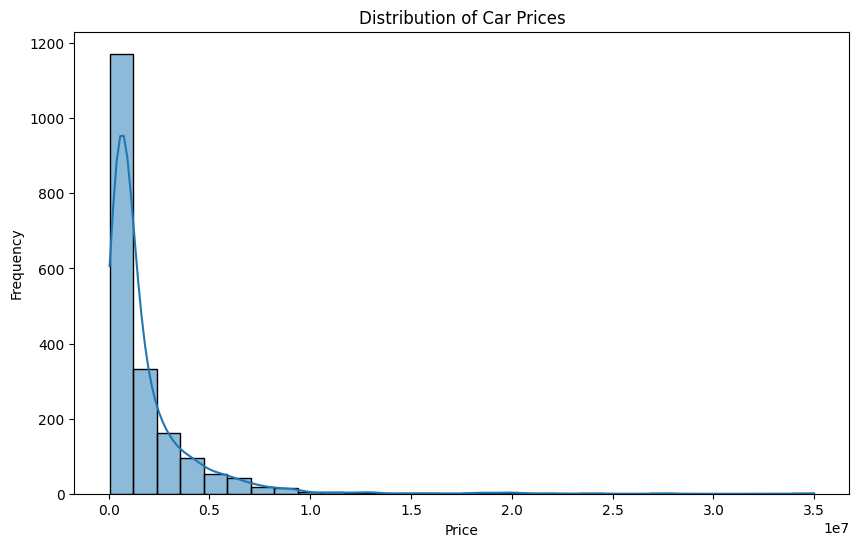

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(df['Price'],
             bins=30,
             kde=True)

plt.title("Distribution of Car Prices")

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

**TOP CAR BRANDS**

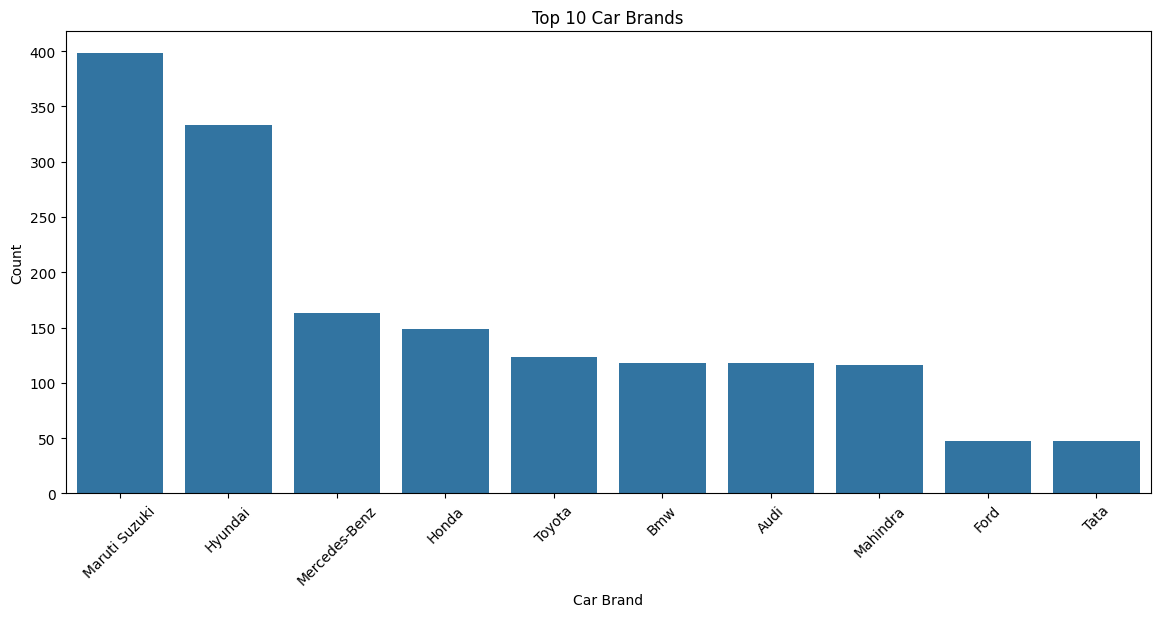

In [30]:
plt.figure(figsize=(14,6))

top_brands = df['Make'].value_counts().head(10)

sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.title("Top 10 Car Brands")

plt.xlabel("Car Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**TOP CAR MODELS**

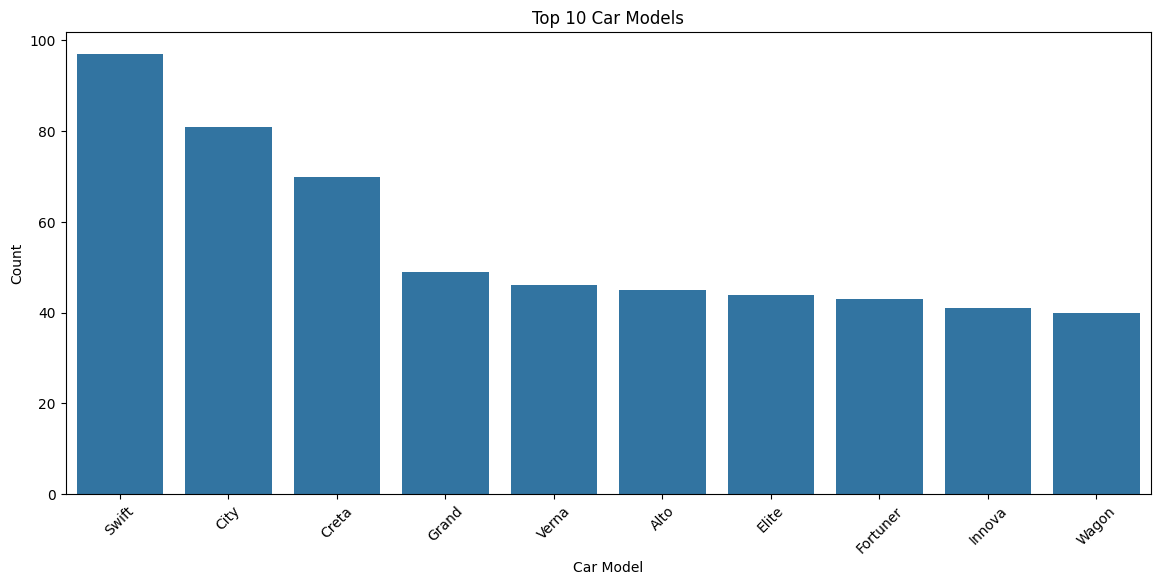

In [31]:
plt.figure(figsize=(14,6))

top_models = df['Model'].value_counts().head(10)

sns.barplot(
    x=top_models.index,
    y=top_models.values
)

plt.title("Top 10 Car Models")

plt.xlabel("Car Model")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**FUEL TYPE DISTRIBUTION**

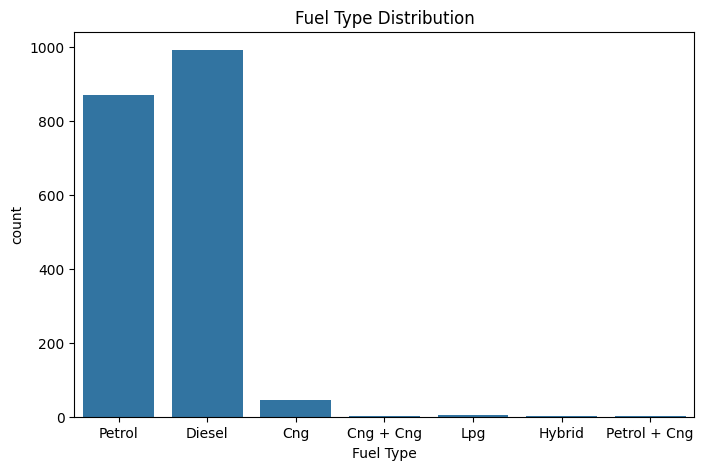

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(x='Fuel Type', data=df)

plt.title("Fuel Type Distribution")

plt.show()

**TRANSMISSION DISTRIBUTION**

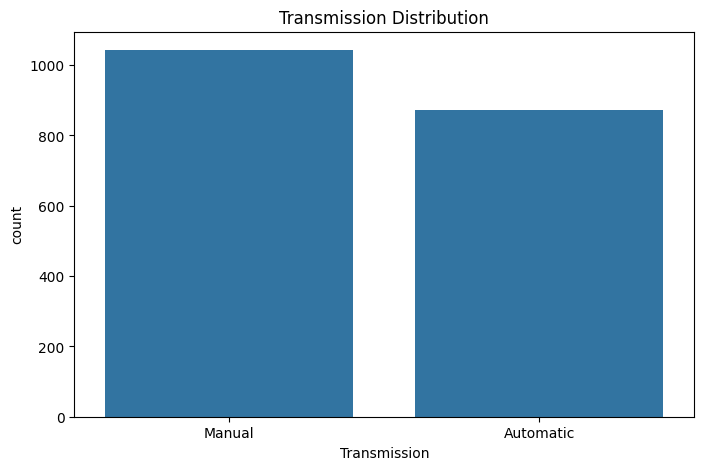

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(x='Transmission', data=df)

plt.title("Transmission Distribution")

plt.show()

**DRIVETRAIN DISTRIBUTION**

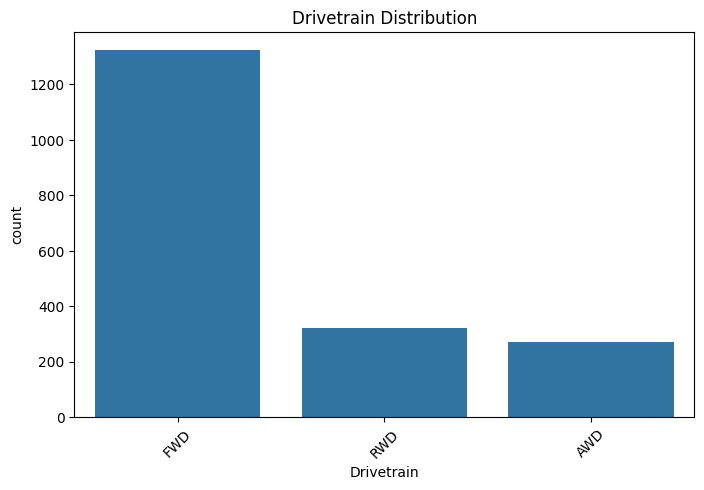

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(x='Drivetrain', data=df)

plt.title("Drivetrain Distribution")

plt.xticks(rotation=45)

plt.show()

**YEAR VS PRICE**

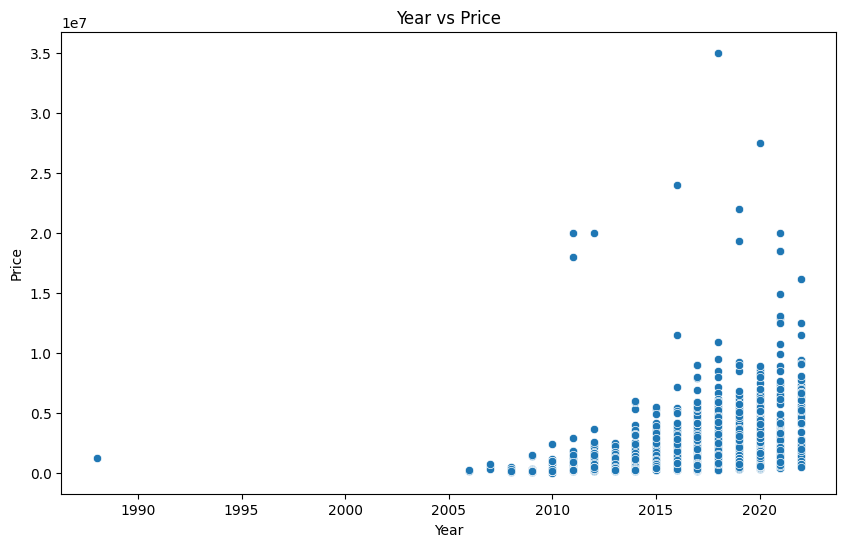

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Year',
    y='Price',
    data=df
)

plt.title("Year vs Price")

plt.show()

**KILOMETER VS PRICE**

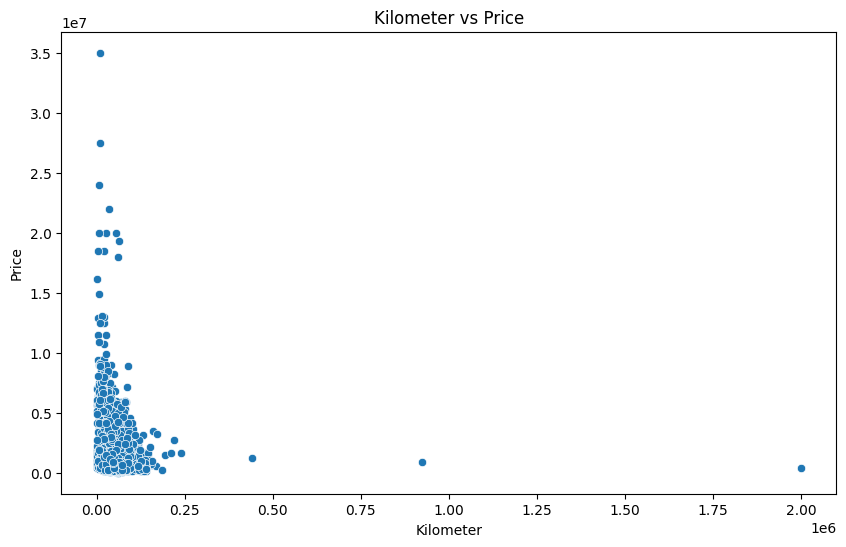

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Kilometer',
    y='Price',
    data=df
)

plt.title("Kilometer vs Price")

plt.show()

**ENGINE VS PRICE**

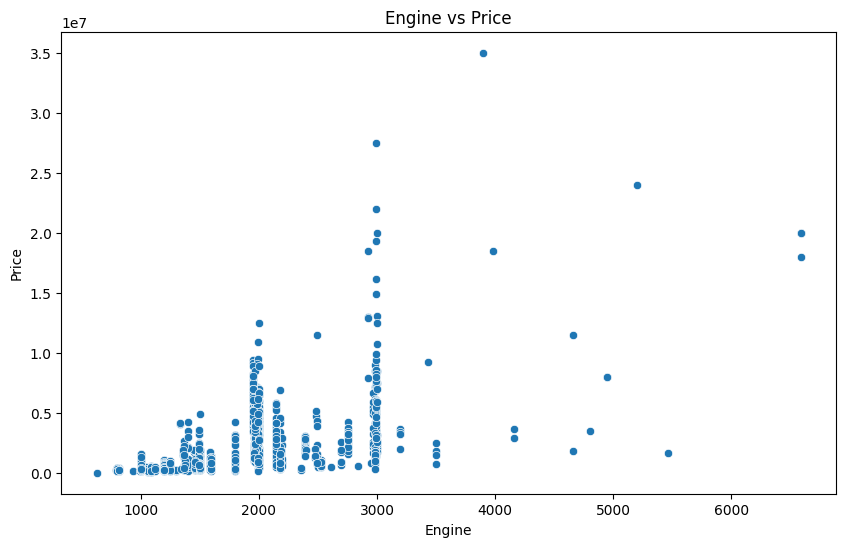

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Engine',
    y='Price',
    data=df
)

plt.title("Engine vs Price")

plt.show()

**PRICE BY FUEL TYPE**

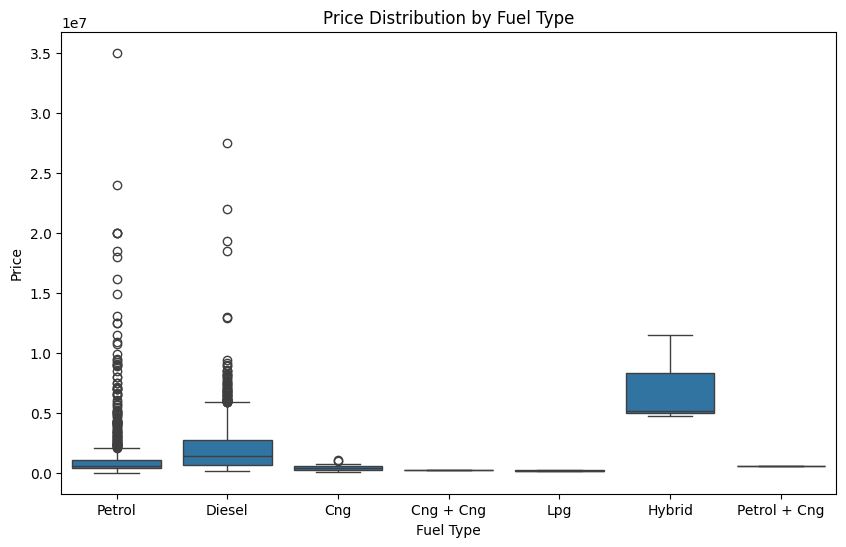

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Fuel Type',
    y='Price',
    data=df
)

plt.title("Price Distribution by Fuel Type")

plt.show()

**PRICE BY TRANSMISSION**

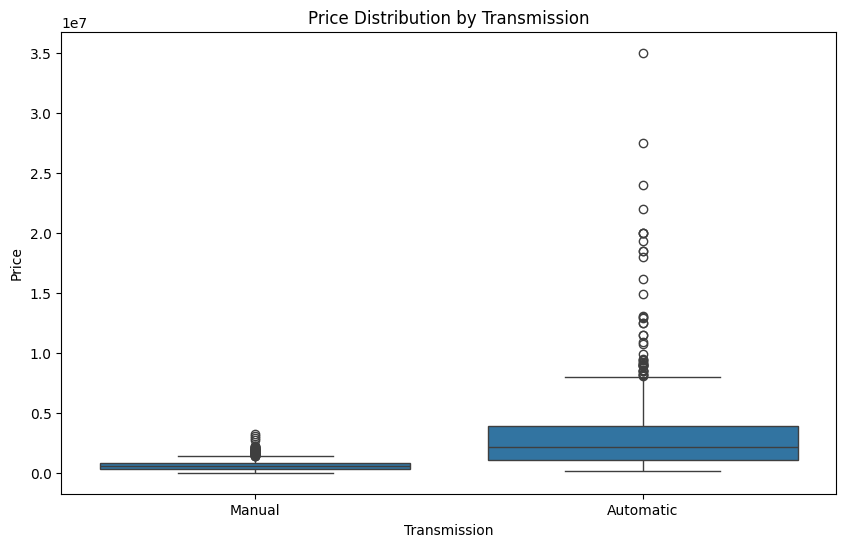

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Transmission',
    y='Price',
    data=df
)

plt.title("Price Distribution by Transmission")

plt.show()

**PRICE BY MODEL (TOP 10)**

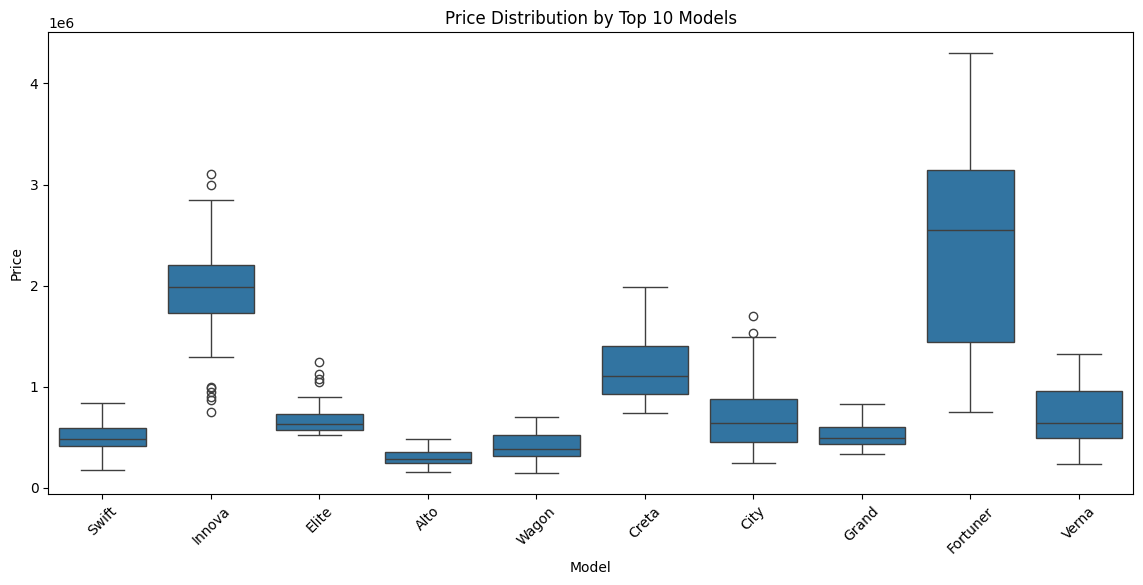

In [40]:
plt.figure(figsize=(14,6))

top_model_list = df['Model'].value_counts().head(10).index
filtered_df = df[df['Model'].isin(top_model_list)]

sns.boxplot(x='Model', y='Price', data=filtered_df)

plt.title("Price Distribution by Top 10 Models")

plt.xticks(rotation=45)

plt.show()

**REGRESSION PLOT**

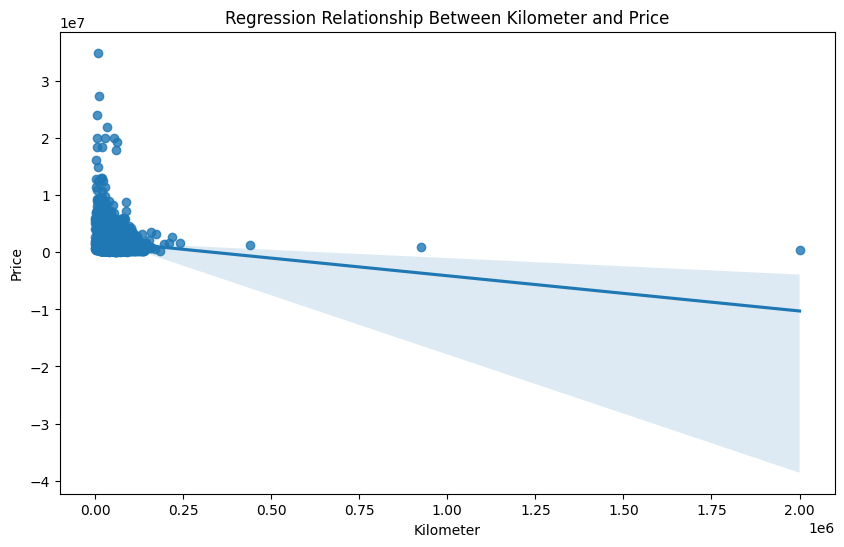

In [41]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='Kilometer',
    y='Price',
    data=df
)

plt.title("Regression Relationship Between Kilometer and Price")

plt.show()

**ENCODING CATEGORICAL FEATURES**

In [42]:
# CREATE COPY
encoded_df = df.copy()

# LABEL ENCODER
le = LabelEncoder()

# CATEGORICAL COLUMNS
categorical_columns = [
    'Make',
    'Model',
    'Fuel Type',
    'Transmission',
    'Drivetrain'
]

# ENCODE COLUMNS
for col in categorical_columns:
    encoded_df[col] = le.fit_transform(encoded_df[col])

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


**CORRELATION MATRIX**

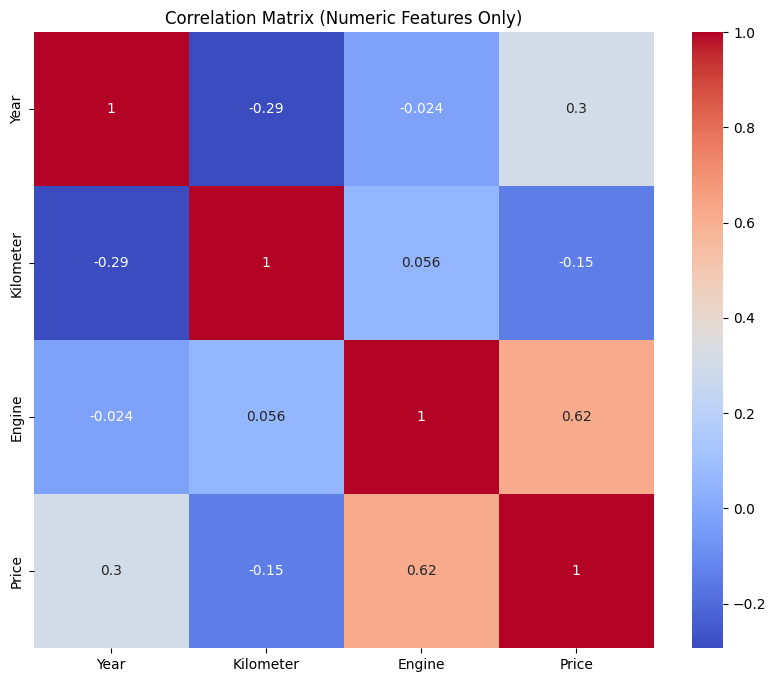

In [43]:
plt.figure(figsize=(10,8))

# ONLY NUMERIC FEATURES FOR MEANINGFUL CORRELATION
num_cols = ['Year', 'Kilometer', 'Engine', 'Price']

correlation_matrix = encoded_df[num_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix (Numeric Features Only)")

plt.show()

**PAIRPLOT**

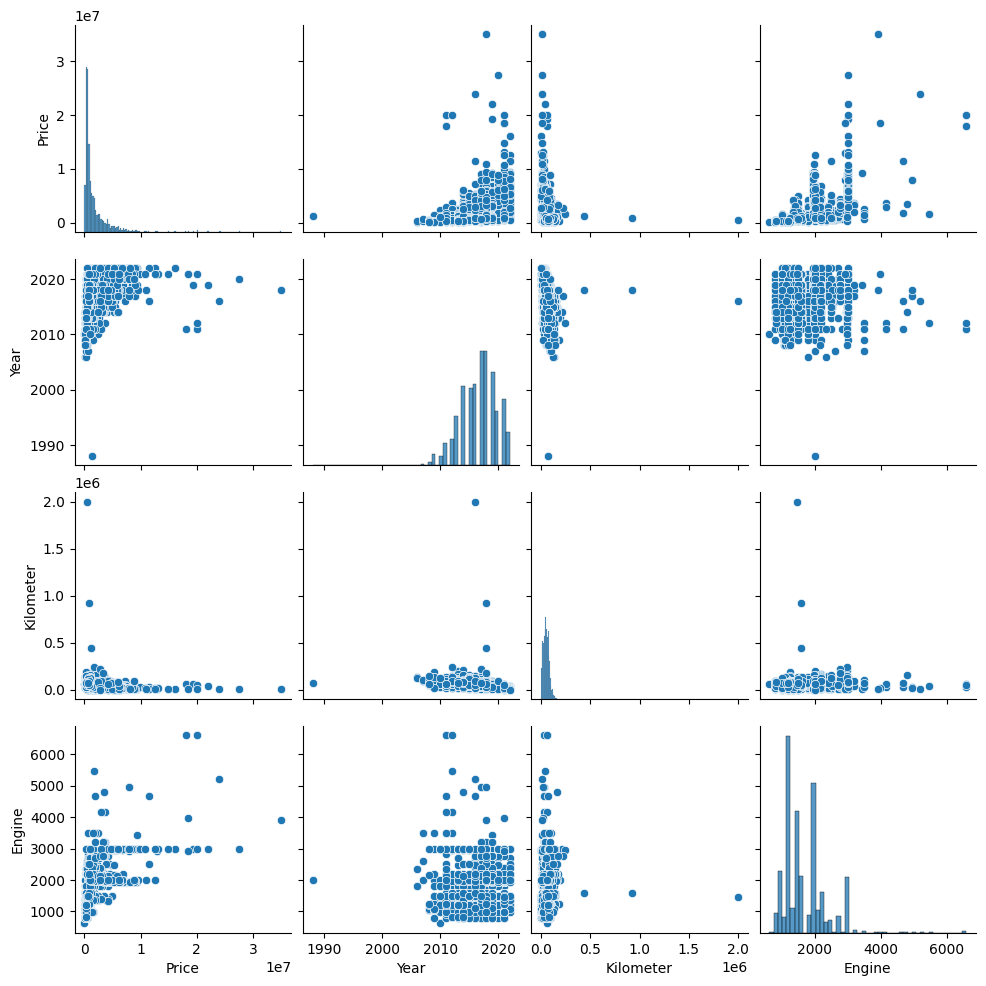

In [44]:
# =========================================================
# PAIRPLOT
# =========================================================

sns.pairplot(
    encoded_df[
        [
            'Price',
            'Year',
            'Kilometer',
            'Engine'
        ]
    ]
)

plt.show()

# **3. Feature Selection**

In [45]:
# INPUT FEATURES
X = df[
    [
        'Make',
        'Model',
        'Year',
        'Kilometer',
        'Fuel Type',
        'Transmission',
        'Drivetrain',
        'Engine'
    ]
]

# TARGET VARIABLE
y = df['Price']

print("Features and Target Selected Successfully!")

Features and Target Selected Successfully!


**DISPLAY INPUT FEATURES**

In [46]:
X.head()

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Drivetrain,Engine
0,Honda,Amaze,2017,87150,Petrol,Manual,FWD,1198
1,Maruti Suzuki,Swift,2014,75000,Diesel,Manual,FWD,1248
2,Hyundai,I10,2011,67000,Petrol,Manual,FWD,1197
3,Toyota,Glanza,2019,37500,Petrol,Manual,FWD,1197
4,Toyota,Innova,2018,69000,Diesel,Manual,RWD,2393


**DISPLAY TARGET VARIABLE**

In [47]:
y.head()

,Price
0,505000
1,450000
2,220000
3,799000
4,1950000


**ENCODING MAKE COLUMN**

In [48]:
make_encoder = LabelEncoder()

X['Make'] = make_encoder.fit_transform(X['Make'])

print("Make Column Encoded Successfully!")

Make Column Encoded Successfully!


**ENCODING ALL CATEGORICAL FEATURES**

In [49]:
# COPY DATA
X_encoded = X.copy()

# SINGLE ENCODER FOR ALL CATEGORICAL COLUMNS
le = LabelEncoder()

categorical_columns = [
    'Make',
    'Model',
    'Fuel Type',
    'Transmission',
    'Drivetrain'
]

# ENCODE ALL TOGETHER
for col in categorical_columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

print("All Categorical Features Encoded Successfully!")

All Categorical Features Encoded Successfully!


**DISPLAY ENCODED FEATURES**

In [50]:
X_encoded.head()

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Drivetrain,Engine
0,7,20,2017,87150,5,1,1,1198
1,17,138,2014,75000,2,1,1,1248
2,8,83,2011,67000,5,1,1,1197
3,30,72,2019,37500,5,1,1,1197
4,30,86,2018,69000,2,1,2,2393


**VERIFYING DATA TYPES AFTER ENCODING**

In [51]:
print(X_encoded.dtypes)

Make            int64
Model           int64
Year            int64
Kilometer       int64
Fuel Type       int64
Transmission    int64
Drivetrain      int64
Engine          int64
dtype: object


**ENCODING SETUP**

In [52]:
make_encoder = LabelEncoder()
model_encoder = LabelEncoder()
fuel_encoder = LabelEncoder()
transmission_encoder = LabelEncoder()
drivetrain_encoder = LabelEncoder()

# FIT ENCODERS ON DATA
make_encoder.fit(df['Make'])
model_encoder.fit(df['Model'])
fuel_encoder.fit(df['Fuel Type'])
transmission_encoder.fit(df['Transmission'])
drivetrain_encoder.fit(df['Drivetrain'])

print("All Encoders Created Successfully!")

All Encoders Created Successfully!


**FINAL FEATURE SHAPE**

In [53]:
# =========================================================
# FINAL FEATURE SHAPE
# =========================================================

print("Feature Shape :", X_encoded.shape)
print("Target Shape :", y.shape)

Feature Shape : (1916, 8)
Target Shape : (1916,)


# **4. Train-Test Split**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape :", X_test.shape)

print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape :", y_test.shape)

Training Features Shape : (1532, 8)
Testing Features Shape : (384, 8)
Training Labels Shape : (1532,)
Testing Labels Shape : (384,)


**CREATING RANDOM FOREST REGRESSOR MODEL**

In [55]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")
print(type(model))

Model Trained Successfully!
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


**SAVING MODEL**

In [56]:
import joblib

joblib.dump(model, 'car_price_prediction_model.pkl')

print("Model saved successfully!")

Model saved successfully!


**VERIFYING MODEL**

In [57]:
import os

print(os.path.exists('car_price_prediction_model.pkl'))

True


# **5. Visualization of Testing & Evaluation**

In [58]:
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


**MAKING PREDICTIONS**

In [59]:
y_pred = model.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


**ACTUAL VS PREDICTED VALUES**

In [60]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,795000,751185.00
1,390000,391290.00
2,445000,433529.99
3,395000,375219.92
4,434000,421649.77
5,585000,875399.98
6,1175000,1157250.00
7,475000,632899.94
8,285000,286050.00
9,1485000,1203449.96


**MEAN ABSOLUTE ERROR**

In [61]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 379826.31879030255


**ROOT MEAN SQUARED ERROR**

In [62]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error :", rmse)

Root Mean Squared Error : 877467.6192001991


**R2 SCORE**

In [63]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.7989684162318967


**ACTUAL VS PREDICTED GRAPH**

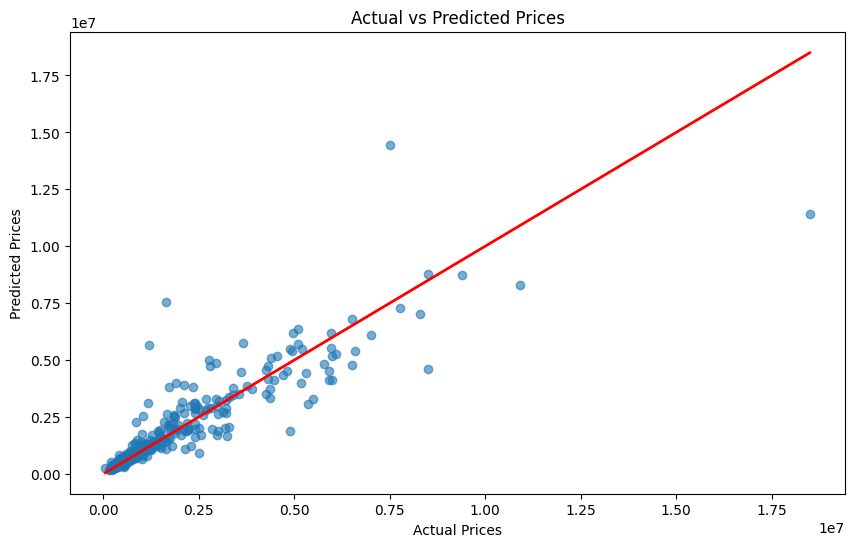

In [64]:
plt.figure(figsize=(10,6))

# scatter plot
plt.scatter(y_test, y_pred, alpha=0.6)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

**FEATURE IMPORTANCE GRAPH**

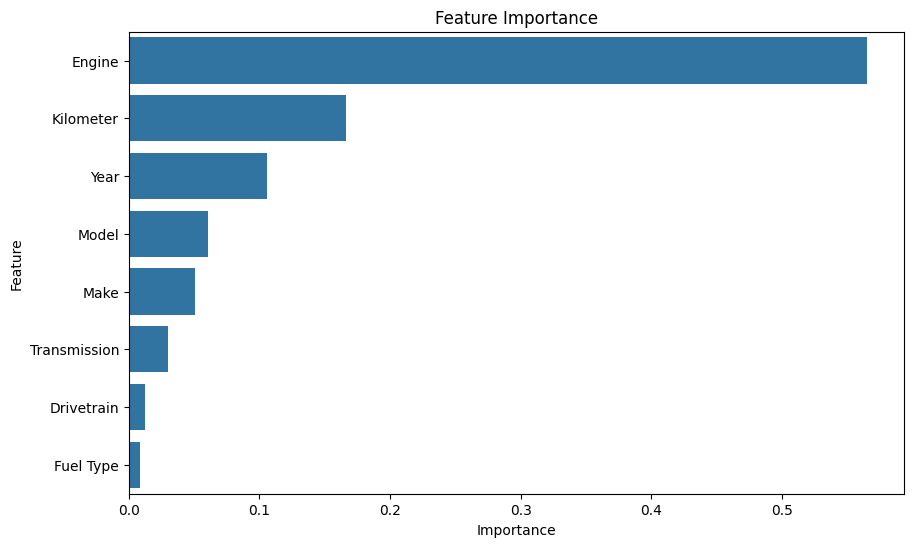

In [65]:
importance = model.feature_importances_

feature_names = X_encoded.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance")

plt.show()

**AVAILABLE OPTIONS FOR USER INPUT88**

In [66]:
print("AVAILABLE CAR MAKES:")
print(df['Make'].unique())

print("\nAVAILABLE CAR MODELS:")
print(df['Model'].unique())

print("\nAVAILABLE FUEL TYPES:")
print(df['Fuel Type'].unique())

print("\nAVAILABLE TRANSMISSIONS:")
print(df['Transmission'].unique())

print("\nAVAILABLE DRIVETRAINS:")
print(df['Drivetrain'].unique())

AVAILABLE CAR MAKES:
['Honda' 'Maruti Suzuki' 'Hyundai' 'Toyota' 'Mercedes-Benz' 'Bmw' 'Skoda'
 'Nissan' 'Renault' 'Tata' 'Volkswagen' 'Ford' 'Audi' 'Mahindra' 'Mg'
 'Jeep' 'Porsche' 'Kia' 'Land Rover' 'Volvo' 'Maserati' 'Jaguar' 'Isuzu'
 'Mini' 'Ferrari' 'Mitsubishi' 'Datsun' 'Lamborghini' 'Chevrolet'
 'Ssangyong' 'Fiat' 'Rolls-Royce' 'Lexus']

AVAILABLE CAR MODELS:
['Amaze' 'Swift' 'I10' 'Glanza' 'Innova' 'Ciaz' 'Cla' 'X1' 'Octavia'
 'Terrano' 'Elite' 'Kwid' 'Harrier' 'Polo' 'Celerio' 'Alto' 'Baleno'
 'Wagon' 'Creta' 'S' 'Vento' 'Santro' 'Venue' 'Ritz' 'Brio' 'Wr'
 'Ecosport' 'Tiago' 'Tigor' 'Glc' 'M' 'Corolla' 'A4' 'Slk' 'Thar' 'Hector'
 'X3' 'Compass' 'Scorpio' '3' 'City' 'Vitara' 'Eeco' 'Grand' 'Fortuner'
 'Civic' 'A3' 'Figo' 'Jazz' 'Camry' 'C' 'Q3' 'Dzire' 'X5' 'Cayenne'
 'Verna' 'A6' 'Xuv300' 'E' 'Zest' 'Rapid' 'Ertiga' 'Q2' 'Q7' '5' 'Q5'
 'Duster' 'I20' 'Marazzo' 'Seltos' 'Discovery' 'Gle' 'Xcent' 'Astor' 'Cr'
 'Fabia' 'Sonet' 'Xuv500' 'Gla' 'V40' 'Nexon' 'Rs5' 'R' 'Safari' 'Le

**USER INPUT SECTION**

In [67]:
make = input("Enter Car Make: ")
model = input("Enter Car Model: ")
year = int(input("Enter Year: "))
kilometer = int(input("Enter Kilometers: "))
fuel = input("Enter Fuel Type: ")
transmission = input("Enter Transmission: ")
drivetrain = input("Enter Drivetrain: ")
engine = float(input("Enter Engine: "))

Enter Car Make: Honda
Enter Car Model: Civic
Enter Year: 2025
Enter Kilometers: 1200
Enter Fuel Type: Petrol
Enter Transmission: Automatic
Enter Drivetrain: FWD
Enter Engine: 1800


**ENCODING VALUES**

In [68]:
make_encoded = make_encoder.transform([make])[0]
model_encoded = model_encoder.transform([model])[0]
fuel_encoded = fuel_encoder.transform([fuel])[0]
transmission_encoded = transmission_encoder.transform([transmission])[0]
drivetrain_encoded = drivetrain_encoder.transform([drivetrain])[0]

**CREATING INPUT ARRAY**

In [69]:
input_data = np.array([[
    make_encoded,
    model_encoded,
    year,
    kilometer,
    fuel_encoded,
    transmission_encoded,
    drivetrain_encoded,
    engine
]])

**IMPORT JOBLIB + LOAD MODEL**

In [70]:
loaded_model = joblib.load('car_price_prediction_model.pkl')

print("Loaded successfully!")
print(type(loaded_model))

Loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [71]:
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


**CAR PRICE PREDICTION**

In [72]:
predicted_price = loaded_model.predict(input_data)

print("Estimated Price:", predicted_price[0])

Estimated Price: 1730399.93


**SAVING TRAINED MODEL**

In [73]:
joblib.dump(model, 'car_price_prediction_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


**SAVING ALL ENCODERS**

In [74]:
# SAVE MAKE ENCODER

joblib.dump(make_encoder, 'make_encoder.pkl')

# SAVE FUEL ENCODER

joblib.dump(fuel_encoder, 'fuel_encoder.pkl')

# SAVE TRANSMISSION ENCODER

joblib.dump(
    transmission_encoder,
    'transmission_encoder.pkl'
)

# SAVE DRIVETRAIN ENCODER

joblib.dump(
    drivetrain_encoder,
    'drivetrain_encoder.pkl'
)

print("All Encoders Saved Successfully!")

All Encoders Saved Successfully!


**LOADING SAVED MODEL**

In [75]:
loaded_model = joblib.load(
    'car_price_prediction_model.pkl'
)

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!
